# Phase II: Exploratory Data Analysis (EDA) — Job Descriptions (Advanced)

This notebook focuses on role-specific skill distributions and vocabulary analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Dataset (Sampled)
Using 50,000 rows for analysis.

In [2]:
JOBS_PATH = "../data/raw/jobs/job_descriptions.csv"
df_jobs = pd.read_csv(JOBS_PATH, nrows=50000)
print(f"Sampled Dataset Shape: {df_jobs.shape}")

Sampled Dataset Shape: (50000, 23)


## 2. Skill-Role Association Heatmap
Which skills are most associated with which roles?

C:\Users\My Device\AppData\Local\Temp\ipykernel_15888\3822753857.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['skill_list'] = sub_df['skills'].fillna('').apply(lambda x: [s.strip() for s in x.split(',')])


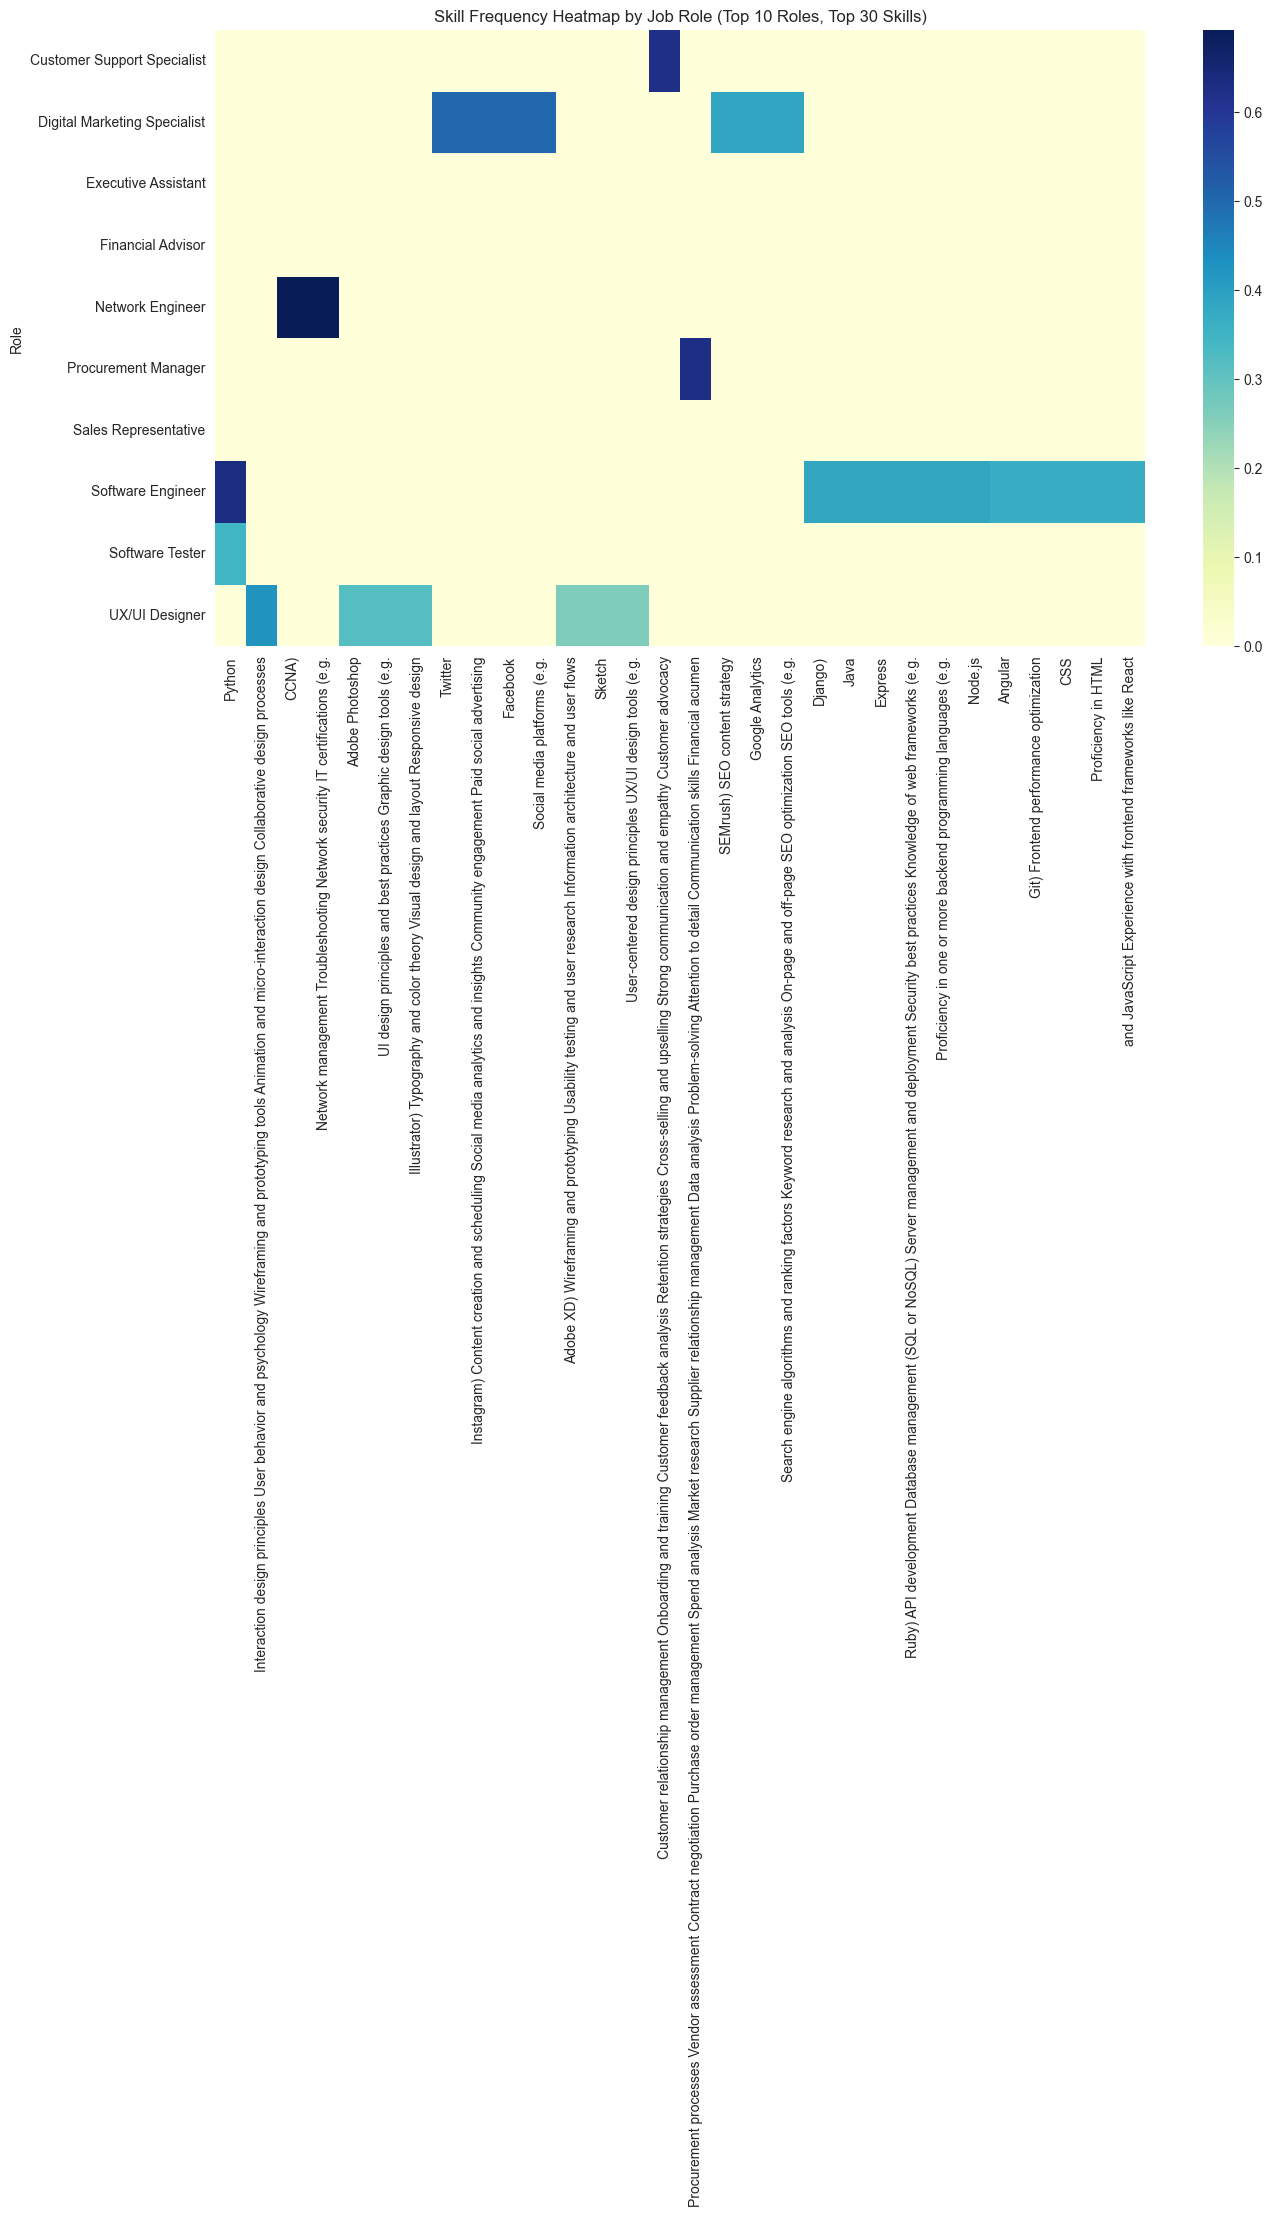

In [3]:
top_roles = df_jobs['Job Title'].value_counts().head(10).index
sub_df = df_jobs[df_jobs['Job Title'].isin(top_roles)]

# Extract skills into a binary matrix
from sklearn.preprocessing import MultiLabelBinarizer

sub_df['skill_list'] = sub_df['skills'].fillna('').apply(lambda x: [s.strip() for s in x.split(',')])
mlb = MultiLabelBinarizer()
skill_matrix = mlb.fit_transform(sub_df['skill_list'])
skills_df = pd.DataFrame(skill_matrix, columns=mlb.classes_)

# Top 30 most frequent skills in this subset
top_skills = skills_df.sum().sort_values(ascending=False).head(30).index
skills_df = skills_df[top_skills]
skills_df['Role'] = sub_df['Job Title'].values

# Pivot to get frequency mean
role_skill_pivot = skills_df.groupby('Role').mean()

plt.figure(figsize=(15, 8))
sns.heatmap(role_skill_pivot, cmap='YlGnBu', annot=False)
plt.title("Skill Frequency Heatmap by Job Role (Top 10 Roles, Top 30 Skills)")
plt.show()

## 3. Benefits vs Qualifications Analysis
Compare the complexity of what's offered vs what's required.

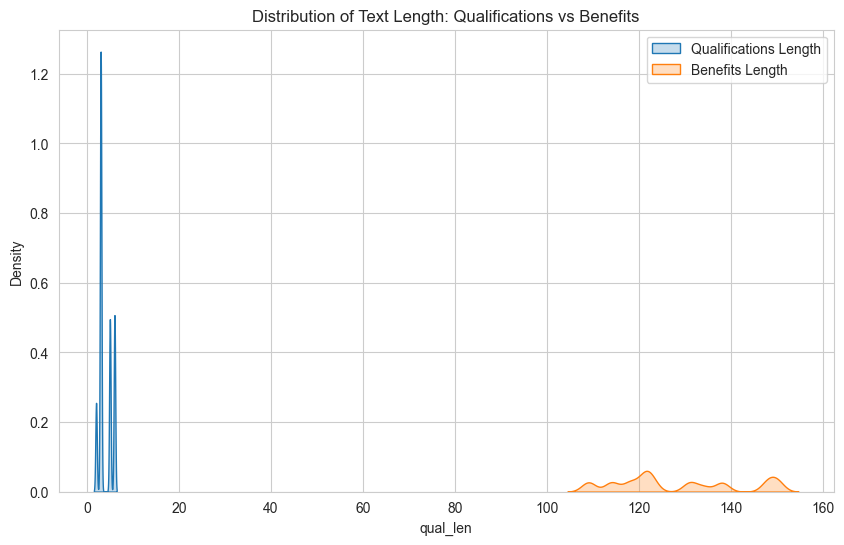

In [4]:
df_jobs['qual_len'] = df_jobs['Qualifications'].astype(str).apply(len)
df_jobs['benefits_len'] = df_jobs['Benefits'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.kdeplot(df_jobs['qual_len'], label='Qualifications Length', fill=True)
sns.kdeplot(df_jobs['benefits_len'], label='Benefits Length', fill=True)
plt.title("Distribution of Text Length: Qualifications vs Benefits")
plt.legend()
plt.show()

## 4. Salary Range Insight (if available)
Extracting basic salary info.

In [5]:
if 'Salary Range' in df_jobs.columns:
    print("Example Salary Ranges:")
    print(df_jobs['Salary Range'].value_counts().head(10))

Example Salary Ranges:
Salary Range
$64K-$88K     115
$64K-$120K    114
$57K-$82K     113
$57K-$95K     113
$65K-$121K    112
$62K-$104K    112
$55K-$90K     111
$60K-$102K    111
$63K-$94K     111
$55K-$111K    110
Name: count, dtype: int64
